# 03. A Hit And A Miss: HUXt Arrival Detection

This notebook runs HUXt for **two Cone-CMEs that differ only in pointing direction** - one aimed at Earth (a **hit**) and the same CME rotated ~130 deg away in longitude (a **miss**) - and shows exactly what the arrival *detector* does: reduce each Earth solar-wind speed series `Vsw(t)` to a hit/miss label plus an arrival time.

That reduction is the heart of `gp_huxt_surrogate.py`'s `run` step (every design sample is collapsed this way) and of its `visualize-threshold` diagnostic. We reproduce both of `visualize-threshold`'s plots inline: the **time-series detector** panel and a **heliosphere snapshot**.

**Detector modes** (the `--detector-method` flag): `enhancement` triggers on a sustained speed rise above a recent baseline; `jump` on a short-lag fractional jump; `front` on HUXt's tracked Cone-CME front reaching Earth; `hybrid` (the default) requires *both* a front crossing and an enhancement.

> **Needs a boundary.** This notebook runs HUXt, so it needs the event's `v_boundary_<event>.npz`. Run notebook 02 first (it writes one) or `python scripts/generate_huxt_input.py --event <event>`.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
if (cwd / "scripts").exists():
    BASE_DIR = cwd
elif (cwd.parent / "scripts").exists():
    BASE_DIR = cwd.parent
else:
    # Fallback: assume the notebook is run from inside the repo.
    BASE_DIR = cwd

SCRIPT_DIR = BASE_DIR / "scripts"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

print("BASE_DIR =", BASE_DIR)

BASE_DIR = /Users/u0167590/github/anwesha/conecast


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import gp_huxt_surrogate as gp

DATA_ROOT = BASE_DIR / "data_dir" / "sw"
event = "2017-09-06"
PARAM_NAMES = gp.PARAM_NAMES   # ["inject_hour", "longitude", "latitude", "width", "v"]

boundary_file = DATA_ROOT / event / f"v_boundary_{event}.npz"
if not boundary_file.exists():
    raise FileNotFoundError(
        f"No boundary {boundary_file}.\n"
        f"Run notebook 02 first (it downloads GONG, runs WSA+, writes the boundary),\n"
        f"or: python scripts/generate_huxt_input.py --event {event}."
    )

# HUXt context: inner-boundary speed map + Carrington rotation + seed Cone-CME vector.
ctx = gp.load_huxt_context(event, DATA_ROOT)
huxt_kwargs, theta0 = ctx["huxt_kwargs"], ctx["theta0"]
print("event:", event, "| seed theta0:", theta0)

event: 2017-09-06 | seed theta0: [   2.71666667   23.          -15.           88.         1238.        ]


## Two Cone-CMEs: aimed at Earth vs rotated away

We take the event's seed Cone-CME and make a second copy that is identical **except for its longitude**, rotated ~130 deg so it points away from Earth. Changing only one parameter isolates the cause: the same launch time, latitude, width, and speed - just a different direction - flips the outcome from hit to miss.

In [3]:
hit_theta = theta0.copy()                  # the seed: a wide CME aimed near Earth
miss_theta = theta0.copy()
miss_theta[1] = theta0[1] + 127.0          # rotate longitude ~130 deg away from Earth

display(pd.DataFrame(
    {"hit (aimed at Earth)": hit_theta, "miss (rotated away)": miss_theta},
    index=PARAM_NAMES,
))

,hit (aimed at Earth),miss (rotated away)
inject_hour,2.716667,2.716667
longitude,23.000000,150.000000
latitude,-15.000000,-15.000000
width,88.000000,88.000000
v,1238.000000,1238.000000


## Run HUXt and detect the arrival

For each CME we call `run_huxt_model()` (build the model + Cone-CME, solve, pull the Earth time series), then `arrival_diagnostics()` to compute the detector internals (smoothed speed, the enhancement curve, the threshold crossing) and `front_arrival_metrics()` for the geometric front. This runs HUXt twice - a minute or two.

In [4]:
def run_case(name, theta):
    model, t, v, cme = gp.run_huxt_model(theta, huxt_kwargs)
    diag = gp.arrival_diagnostics(t, v, threshold=0.25, method="enhancement")
    front = gp.front_arrival_metrics(cme, t)
    print(f"{name}: enhancement hit={diag['hit']}, front hit={front['front_hit']}, "
          f"peak Vsw={diag['peak_vsw']:.0f} km/s")
    return {"name": name, "theta": theta, "model": model, "cme": cme, "diag": diag, "front": front}

hit = run_case("hit (aimed at Earth)", hit_theta)
miss = run_case("miss (rotated away)", miss_theta)

/Users/u0167590/miniforge3/envs/huxt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-07 15:03:27 - astropy - WARNING: XDG_CACHE_HOME is set to '/Users/u0167590/github/anwesha/conecast/.cache', but the default location, /Users/u0167590/.astropy/cache, already exists, and takes precedence. This environment variable will be ignored.


hit (aimed at Earth): enhancement hit=True, front hit=True, peak Vsw=827 km/s
miss (rotated away): enhancement hit=False, front hit=False, peak Vsw=579 km/s


/Users/u0167590/miniforge3/envs/huxt/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


## The threshold diagnostic plot

This is the **time-series panel** `visualize-threshold` writes. Top: the Earth solar-wind speed (raw + smoothed), with a line at the detected arrival. Bottom: the enhancement detector against the `0.25` threshold. For the hit, the smoothed speed jumps and the detector crosses the threshold; for the miss, the CME never reaches Earth, so the speed stays at the ambient background and the detector never crosses.

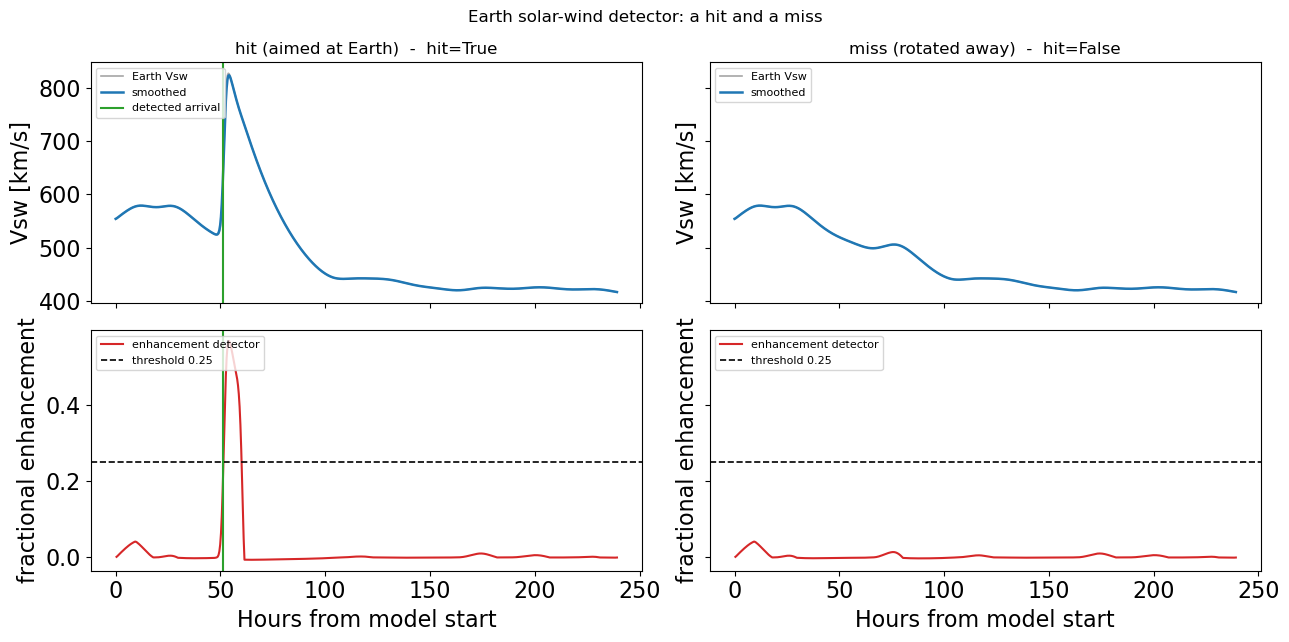

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), sharex=True, sharey="row")
for col, case in enumerate([hit, miss]):
    d = case["diag"]
    top, bot = axes[0, col], axes[1, col]
    top.plot(d["hours"], d["speed"], color="0.65", lw=1.2, label="Earth Vsw")
    top.plot(d["hours"], d["smooth_speed"], color="tab:blue", lw=1.8, label="smoothed")
    if d["hit"]:
        top.axvline(d["arrival_time_hr"], color="tab:green", lw=1.5, label="detected arrival")
    top.set_title(f"{case['name']}  -  hit={d['hit']}")
    top.set_ylabel("Vsw [km/s]")
    top.legend(loc="upper left", fontsize=8)

    bot.plot(d["hours"], d["detector"], color="tab:red", lw=1.5, label="enhancement detector")
    bot.axhline(d["threshold"], color="k", ls="--", lw=1.2, label=f"threshold {d['threshold']:g}")
    if d["hit"]:
        bot.axvline(d["arrival_time_hr"], color="tab:green", lw=1.5)
    bot.set_xlabel("Hours from model start")
    bot.set_ylabel("fractional enhancement")
    bot.legend(loc="upper left", fontsize=8)
fig.suptitle("Earth solar-wind detector: a hit and a miss", fontsize=12)
fig.tight_layout()

## Hit vs miss summary

The scalar outcomes - one row each - are exactly what `run_design()` writes to `results.csv` and what the GP trains on (Task 3 of notebook 04).

In [6]:
def summary_row(case):
    d, f = case["diag"], case["front"]
    return {
        "case": case["name"],
        "longitude": round(float(case["theta"][1]), 1),
        "hit": d["hit"],
        "arrival_time_hr": d["arrival_time_hr"],
        "max_enhancement": d["max_speed_enhancement"],
        "front_hit": f["front_hit"],
        "peak_vsw": d["peak_vsw"],
    }

display(pd.DataFrame([summary_row(hit), summary_row(miss)]))

,case,longitude,hit,arrival_time_hr,max_enhancement,front_hit,peak_vsw
0,hit (aimed at Earth),23.0,True,51.4045,0.569615,True,826.675469
1,miss (rotated away),150.0,False,NaN,0.041547,False,578.643149


## Heliosphere snapshot

The **second plot** `visualize-threshold` writes is a top-down view of the heliosphere, which makes the geometry obvious: the hit CME sweeps over Earth, the miss CME slides past on the far side. We snapshot the hit at its arrival time and the miss partway through the run.

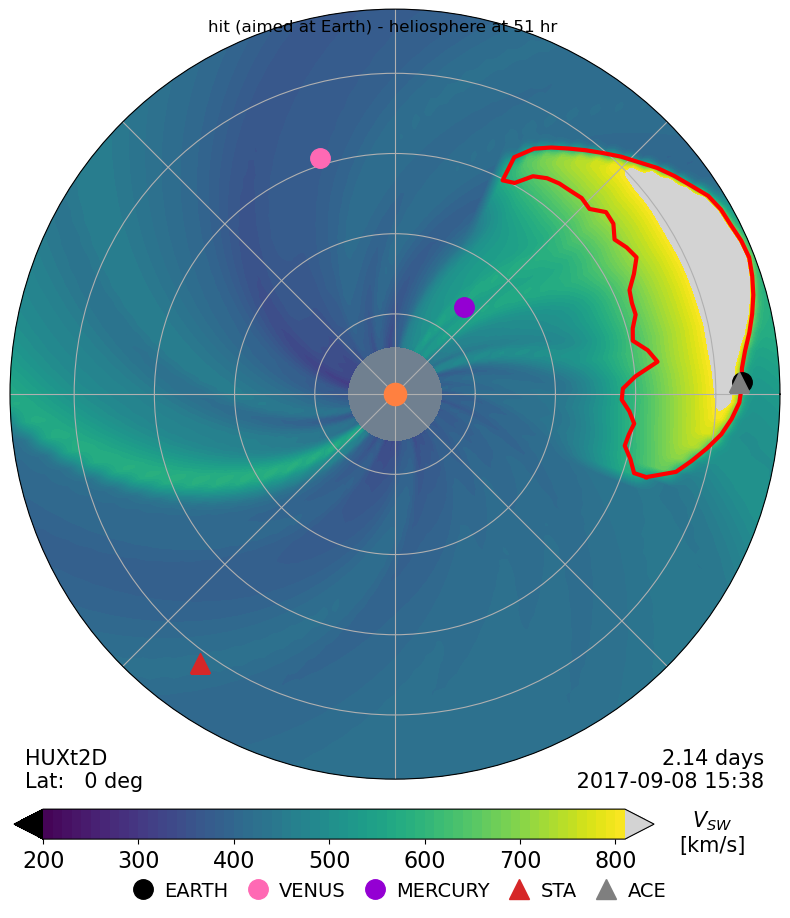

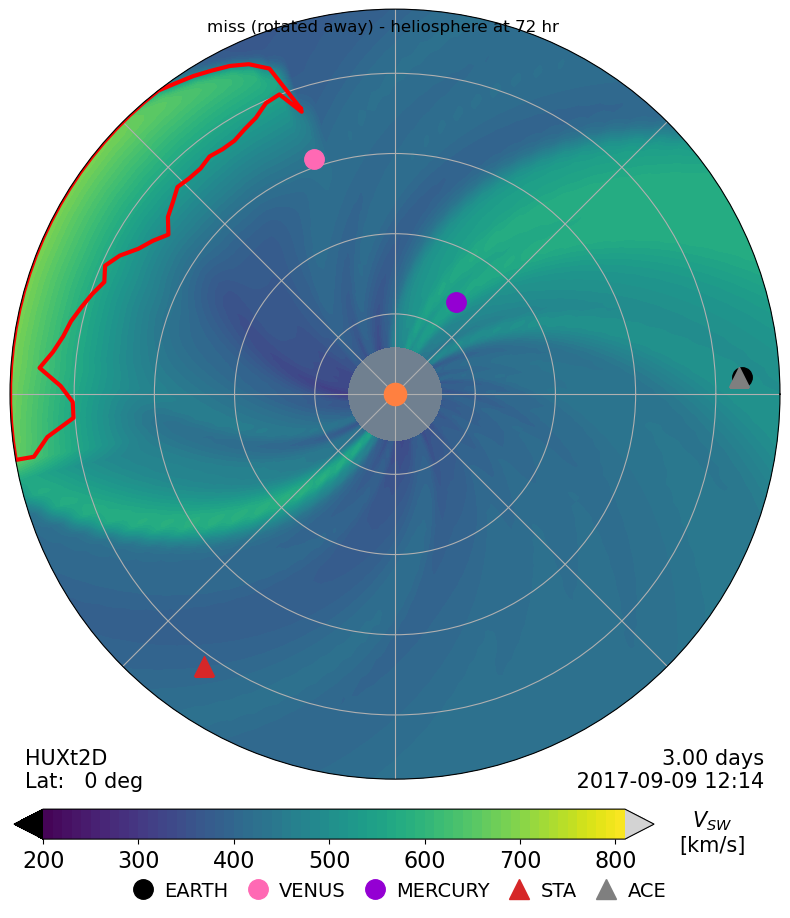

In [7]:
import astropy.units as u
import huxt.huxt_analysis as HA

for case in [hit, miss]:
    d = case["diag"]
    snap = (d["arrival_time_hr"] if d["hit"] else 72.0) * u.hour
    try:
        figh, _ = HA.plot(case["model"], snap, plotHCS=False, trace_earth_connection=False)
        figh.suptitle(f"{case['name']} - heliosphere at {snap.to('hr').value:.0f} hr", y=0.97)
    except Exception as exc:
        print(f"heliosphere snapshot for {case['name']} skipped:", exc)

## What `visualize-threshold` Does

The `run` step reduces *every* design sample to one row of `results.csv` with exactly the detector above. When a case looks like a visual hit but is labelled a miss (or vice-versa), `visualize-threshold` replays selected completed samples and writes the two plots we just reproduced - the time-series detector panel and the heliosphere snapshot - to `runs/gp_surrogate/<event>/figures/threshold_diagnostics/`:

```bash
python scripts/gp_huxt_surrogate.py --event 2017-09-06 visualize-threshold \
  --detector-threshold 0.25 \
  --detector-method enhancement \
  --sample-ids 8
```

`--sample-ids 8` picks sample 8 from `results.csv` (build a batch first via notebook 04 or `gp_huxt_surrogate.py … design/run`). Drop `--sample-ids` to auto-select the strongest near-miss cases instead, and switch `--detector-method` to compare how `enhancement`, `front`, and `hybrid` label the same run.